In [ ]:
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_weaviate.vectorstores import WeaviateVectorStore
from langchain_huggingface import HuggingFaceEmbeddings
from utils import *
import weaviate
import json
from langchain_weaviate.vectorstores import WeaviateVectorStore
import os
from rag.prompt import *
os.getcwd()
%cd ..

/Users/macbook/Documents/Code/uni-guider


In [54]:
model_name = "keepitreal/vietnamese-sbert"
# VoVanPhuc/sup-SimCSE-VietNamese-phobert-base
model_kwargs = {'device': 'cpu'}
encode_kwargs = {'normalize_embeddings': False}
hf = HuggingFaceEmbeddings(
    model_name=model_name,
    model_kwargs=model_kwargs,
    encode_kwargs=encode_kwargs
)

In [ ]:
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from langchain_ollama import ChatOllama
# vilm/vinallama-7b
# VietAI/vit5-base
# Thay tên model huggingface vô cái repo_id
llm = HuggingFaceEndpoint(
    repo_id="vilm/vinallama-7b",
    max_new_tokens=1024,
    do_sample=False,
    repetition_penalty=1.03,
    temperature=0.3,
    task = "text-generation",
)

In [ ]:
data = load_doc_from_json(filename="data/document_langchain.json")
weaviate_client = weaviate.connect_to_local()
vectorstore = WeaviateVectorStore.from_documents(data, hf, client=weaviate_client)
#docker run -p 8080:8080 -p 50051:50051 cr.weaviate.io/semitechnologies/weaviate:1.28.4

In [131]:
retriever = vectorstore.as_retriever(k = 5)

In [132]:
import operator
from typing_extensions import TypedDict
from typing import List, Annotated

class GraphState(TypedDict):
    question: str  # User question
    generation: str  # LLM generation
    web_search: str  # Binary decision to run web search
    max_retries: int  # Max number of retries for answer generation
    answers: int  # Number of answers generated
    loop_step: Annotated[int, operator.add]
    documents: List[str]  # List of retrieved documents

In [133]:
def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)
def retrieve(state):
  
    print("---RETRIEVE---")
    question = state["question"]

    # Write retrieved documents to documents key in state
    documents = retriever.invoke(question)
    return {"documents": documents}
def generate(state):
    # global template
    print("---GENERATE---")
    question = state["question"]
    documents = state["documents"]
    loop_step = state.get("loop_step", 0)

    # RAG generation
    docs_txt = format_docs(documents)
    rag_prompt_formatted = rag_prompt.format(context=docs_txt, question=question)
    generation = llm.invoke([
        # SystemMessage(content=template),
        HumanMessage(content=rag_prompt_formatted)])
    return {"generation": generation, "loop_step": loop_step + 1}

def grade_documents(state):
    
    print("---CHECK DOCUMENT RELEVANCE TO QUESTION---")
    question = state["question"]
    documents = state["documents"]

    # Score each doc
    filtered_docs = []
    # web_search = "No"
    for d in documents:
        doc_grader_prompt_formatted = doc_grader_prompt.format(
            document=d.page_content, question=question
        )
        result = llm.invoke(
            [SystemMessage(content=doc_grader_instructions)]
            + [HumanMessage(content=doc_grader_prompt_formatted)]
        )
        # print("Raw response:", result.content)

        # json_result = json.loads(result.content)
        matches = re.findall(r'\{.*?\}', result, re.DOTALL)  # List of JSON-like strings
        json_result = [json.loads(m) for m in matches] if matches else None  # Convert to JSON
        if json_result and isinstance(json_result, list) and len(json_result) > 0:
            grade = json_result[0].get("binary_score", "no")  # Use .get() to avoid KeyError
        else:
            grade = "no"
        # Document relevant
        if grade.lower() == "yes":
            print("---GRADE: DOCUMENT RELEVANT---")
            filtered_docs.append(d)
        # Document not relevant
        else:
            print("---GRADE: DOCUMENT NOT RELEVANT---")
            # We do not include the document in filtered_docs
            # We set a flag to indicate that we want to run web search
            # web_search = "Yes"
            continue
    return {"documents": filtered_docs}

In [134]:
def grade_generation_v_documents_and_question(state):

    print("---CHECK HALLUCINATIONS---")
    question = state["question"]
    documents = state["documents"]
    generation = state["generation"]
    max_retries = state.get("max_retries", 3)  # Default to 3 if not provided
    hallucination_grader_prompt_formatted = hallucination_grader_prompt.format(
        documents=format_docs(documents), generation=generation
    )
    result = llm.invoke(
        [SystemMessage(content=hallucination_grader_instructions)]
        + [HumanMessage(content=hallucination_grader_prompt_formatted)]
    )
    # print("Raw response:", result.content)

    # json_result = json.loads(result.content)
    matches = re.findall(r'\{.*?\}', result, re.DOTALL)  # List of JSON-like strings
    json_result = [json.loads(m) for m in matches] if matches else None  # Convert to JSON
    if json_result and isinstance(json_result, list) and len(json_result) > 0:
        grade = json_result[0].get("binary_score", "no")  # Use .get() to avoid KeyError
    else:
        grade = "no"
    if grade == "yes":
        print("---DECISION: GENERATION IS GROUNDED IN DOCUMENTS---")
        # Check question-answering
        print("---GRADE GENERATION vs QUESTION---")
        # Test using question and generation from above
        answer_grader_prompt_formatted = answer_grader_prompt.format(
            question=question, generation=generation
        )
        result = llm.invoke(
            [SystemMessage(content=answer_grader_instructions)]
            + [HumanMessage(content=answer_grader_prompt_formatted)]
        )

        # json_result = json.loads(result.content)
        matches = re.findall(r'\{.*?\}', result, re.DOTALL)  # List of JSON-like strings
        json_result = [json.loads(m) for m in matches] if matches else None  # Convert to JSON
        if json_result and isinstance(json_result, list) and len(json_result) > 0:
            grade = json_result[0].get("binary_score", "no")  # Use .get() to avoid KeyError
        else:
            grade = "no"
        # if "binary_score" in json_result:
        #     grade = json_result["binary_score"]
        # else:
        #     print("Warning: 'binary_score' key not found in JSON result")
        #     grade = 'no'

        if grade == "yes":
            print("---DECISION: GENERATION ADDRESSES QUESTION---")
            return "useful" 

        elif state["loop_step"] <= max_retries:
            print("---DECISION: GENERATION DOES NOT ADDRESS QUESTION---")
            return "not useful"  

        else:
            print("---DECISION: MAX RETRIES REACHED---")
            return "max retries"  

    elif state["loop_step"] <= max_retries:
        print("---DECISION: GENERATION IS NOT GROUNDED IN DOCUMENTS, RE-TRY---")
        return "not supported"  

    else:
        print("---DECISION: MAX RETRIES REACHED---")
        return "max retries"  


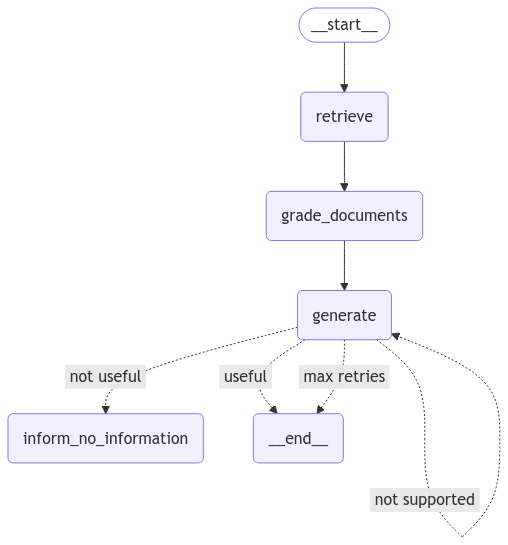

In [135]:
from langgraph.graph import StateGraph
from langgraph.graph import START, StateGraph
from langgraph.graph import END

from IPython.display import Image, display
workflow = StateGraph(GraphState)
workflow.add_node("retrieve", retrieve)
workflow.add_node("grade_documents", grade_documents)
workflow.add_node("generate", generate)
# workflow.add_node("grade_generation_v_documents_and_question", grade_generation_v_documents_and_question)
workflow.add_node(
    "inform_no_information",
    lambda: "Xin lỗi, nhưng chúng tôi không được cung cấp thông tin cho vấn đề này.",
    # end=True,  # Marks this as the final step
)

workflow.add_edge("retrieve", "grade_documents")
workflow.add_edge("grade_documents", "generate")
workflow.add_conditional_edges(
    "generate",
    grade_generation_v_documents_and_question,
    {
        "not supported": "generate",
        "useful": END,
        "not useful": "inform_no_information",
        "max retries": END,
    },
)
workflow.set_entry_point("retrieve")

app = workflow.compile()
display(Image(app.get_graph().draw_mermaid_png()))

In [136]:
question = input("Bạn muốn hỏi gì: ")
inputs = {
    "question": question,
    "max_retries": 3,
}
for event in app.stream(inputs, stream_mode="values"):
    print(event)

{'question': 'Kể về một số hoạt động ngoại khoá của Đại học Bách Khoa?', 'max_retries': 3, 'loop_step': 0}
---RETRIEVE---
{'question': 'Kể về một số hoạt động ngoại khoá của Đại học Bách Khoa?', 'max_retries': 3, 'loop_step': 0, 'documents': [Document(metadata={'title': 'Sổ tay sinh viên 2024 và tài liệu tuần định hướng', 'source': 'https://ctsv.hust.edu.vn/#/nhap-hoc/thong-tin/117/so-tay-sinh-vien-2024-va-tai-lieu-tuan-dinh-huong', 'category': 'freshman_knowledge'}, page_content='Sổ tay sinh viên 2024 và tài liệu tuần định hướng\nCập nhật: 09:27 23/10/2024\nChào mừng HUSTer K69 đến với Đại học Bách khoa Hà Nội, nơi bạn sẽ học tập, rèn luyện và trải nghiệm 4 đến 5 năm thanh xuân của bạn!\nVới thông điệp “Sinh viên Bách khoa ra biển lớn”, Đại học BKHN tự hào là một trong những ngôi trường đào tạo chuyên gia, nhà kỹ thuật hàng đầu Việt Nam, nơi giúp các bạn trang bị các Kiến thức - Kỹ năng - Tư duy làm việc cần thiết, kiến tạo sự thành công trong tương lại. Bên cạnh học tập, 

/Users/macbook/miniconda3/envs/uni_guider/lib/python3.9/site-packages/huggingface_hub/utils/_deprecation.py:131: FutureWarning: 'post' (from 'huggingface_hub.inference._client') is deprecated and will be removed from version '0.31.0'. Making direct POST requests to the inference server is not supported anymore. Please use task methods instead (e.g. `InferenceClient.chat_completion`). If your use case is not supported, please open an issue in https://github.com/huggingface/huggingface_hub.
  warnings.warn(warning_message, FutureWarning)


---GRADE: DOCUMENT RELEVANT---


/Users/macbook/miniconda3/envs/uni_guider/lib/python3.9/site-packages/huggingface_hub/utils/_deprecation.py:131: FutureWarning: 'post' (from 'huggingface_hub.inference._client') is deprecated and will be removed from version '0.31.0'. Making direct POST requests to the inference server is not supported anymore. Please use task methods instead (e.g. `InferenceClient.chat_completion`). If your use case is not supported, please open an issue in https://github.com/huggingface/huggingface_hub.
  warnings.warn(warning_message, FutureWarning)


---GRADE: DOCUMENT RELEVANT---


...

---DECISION: GENERATION IS NOT GROUNDED IN DOCUMENTS, RE-TRY---
{'question': 'Kể về một số hoạt động ngoại khoá của Đại học Bách Khoa?', 'generation': '1. Sổ tay sinh viên 2024.\n2. Tài liệu tuần định hướng K69\nBan Công tác Sinh viên\n\nCẩm nang sinh viên và Cẩm nang Phòng tư vấn\nCập nhật: 05:19 26/03/2024\nĐại học Bách khoa Hà Nội áp dụng quy chế đào tạo theo hệ thống tín chỉ đối với tất cả các ngành học trong toàn Trường từ khóa 52. Đây là hình thức đào tạo tiên tiến đang được áp dụng ở hầu hết các nước trên thế giới. Đào tạo theo tín chỉ là một quy trình đào tạo mềm dẻo, lấy người học làm trung tâm, tạo điều kiện cho sinh viên (sau đây gọi tắt là SV) chủ động xây dựng kế hoạch học tập: Đăng ký môn học, kéo dài hoặc rút ngắn thời gian của khóa học, học song hành hai chương trình,... Để hoàn thành tốt việc học tập tại Trường, ngoài việc nhận được sự hướng dẫn từ giảng viên, cố vấn học tập, các phòng ban chức năng và các tổ chức đoàn thể, mỗi SV phải tự trang bị cho mình những 

/Users/macbook/miniconda3/envs/uni_guider/lib/python3.9/site-packages/huggingface_hub/utils/_deprecation.py:131: FutureWarning: 'post' (from 'huggingface_hub.inference._client') is deprecated and will be removed from version '0.31.0'. Making direct POST requests to the inference server is not supported anymore. Please use task methods instead (e.g. `InferenceClient.chat_completion`). If your use case is not supported, please open an issue in https://github.com/huggingface/huggingface_hub.
  warnings.warn(warning_message, FutureWarning)


---CHECK HALLUCINATIONS---


/Users/macbook/miniconda3/envs/uni_guider/lib/python3.9/site-packages/huggingface_hub/utils/_deprecation.py:131: FutureWarning: 'post' (from 'huggingface_hub.inference._client') is deprecated and will be removed from version '0.31.0'. Making direct POST requests to the inference server is not supported anymore. Please use task methods instead (e.g. `InferenceClient.chat_completion`). If your use case is not supported, please open an issue in https://github.com/huggingface/huggingface_hub.
  warnings.warn(warning_message, FutureWarning)


---DECISION: MAX RETRIES REACHED---
{'question': 'Kể về một số hoạt động ngoại khoá của Đại học Bách Khoa?', 'generation': '1. Sổ tay sinh viên 2024.\n2. Tài liệu tuần định hướng K69\nBan Công tác Sinh viên\n\nCẩm nang sinh viên và Cẩm nang Phòng tư vấn\nCập nhật: 05:19 26/03/2024\nĐại học Bách khoa Hà Nội áp dụng quy chế đào tạo theo hệ thống tín chỉ đối với tất cả các ngành học trong toàn Trường từ khóa 52. Đây là hình thức đào tạo tiên tiến đang được áp dụng ở hầu hết các nước trên thế giới. Đào tạo theo tín chỉ là một quy trình đào tạo mềm dẻo, lấy người học làm trung tâm, tạo điều kiện cho sinh viên (sau đây gọi tắt là SV) chủ động xây dựng kế hoạch học tập: Đăng ký môn học, kéo dài hoặc rút ngắn thời gian của khóa học, học song hành hai chương trình,... Để hoàn thành tốt việc học tập tại Trường, ngoài việc nhận được sự hướng dẫn từ giảng viên, cố vấn học tập, các phòng ban chức năng và các tổ chức đoàn thể, mỗi SV phải tự trang bị cho mình những kiến thức cơ bản liên quan đ

In [137]:
pprint(event['generation'])

('1. Sổ tay sinh viên 2024.\n'
 '2. Tài liệu tuần định hướng K69\n'
 'Ban Công tác Sinh viên\n'
 '\n'
 'Cẩm nang sinh viên và Cẩm nang Phòng tư vấn\n'
 'Cập nhật: 05:19 26/03/2024\n'
 'Đại học Bách khoa Hà Nội áp dụng quy chế đào tạo theo hệ thống tín chỉ đối '
 'với tất cả các ngành học trong toàn Trường từ khóa 52. Đây là hình thức đào '
 'tạo tiên tiến đang được áp dụng ở hầu hết các nước trên thế giới. Đào tạo '
 'theo tín chỉ là một quy trình đào tạo mềm dẻo, lấy người học làm trung tâm, '
 'tạo điều kiện cho sinh viên (sau đây gọi tắt là SV) chủ động xây dựng kế '
 'hoạch học tập: Đăng ký môn học, kéo dài hoặc rút ngắn thời gian của khóa '
 'học, học song hành hai chương trình,... Để hoàn thành tốt việc học tập tại '
 'Trường, ngoài việc nhận được sự hướng dẫn từ giảng viên, cố vấn học tập, các '
 'phòng ban chức năng và các tổ chức đoàn thể, mỗi SV phải tự trang bị cho '
 'mình những kiến thức cơ bản liên quan đến quyền lợi, nghĩa vụ của SV, biết '
 'khai thác thông tin li